# Lab 4: Polynomial Regression and Cross-Validation


---

## Background

Turbidity measures how much light is blocked by suspended particles in water. During a major storm like a hurricane, wind and rainfall stir up sediment and carry organic material into rivers, causing turbidity levels to spike. When light is blocked, aquatic photosynthesis slows, which reduces dissolved oxygen (DO). The relationship between turbidity and DO is not linear; it curves and flattens at extreme values.

In this lab, we use 15-minute continuous sensor data from the Hudson River during **Hurricane Irene (August 25 – September 5, 2011)**, collected by HRECOS. We will:

- Fit a **simple linear regression** as a baseline and compute test MSE
- Check if a **polynomial regression** is a better fit than linear regression
- Use a **for loop with cross-validation** to find the polynomial degrees (from 1 to 10) that yields the best MSE
- Select the best degree and evaluate it on the test set

---

## Setup: Load Libraries and Read in Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

url = "https://docs.google.com/spreadsheets/d/1MsSf679OsQpt4y6btV3tLPf-i8_bdoTZ/export?format=xlsx"

hurricane_do        = pd.read_excel(url, sheet_name=5)
hurricane_turbidity = pd.read_excel(url, sheet_name=2)

# Merge two sheets together and drop locations that aren't Albany
df = hurricane_do.merge(hurricane_turbidity, on='Date Time (ET)').drop(
    ['Piermont D.O. (ppm)', 'Piermont Turbidity in NTU', 'Norrie Point Turbidity in NTU','Norrie Point D.O. (ppm)'], axis=1)

# Rename columns
df.columns = ['date', 'albany_DO', 'albany_turbidity']

print(f'Shape: {df.shape}')
df.head()

Shape: (1152, 3)


,date,albany_DO,albany_turbidity
0,2011-08-25 00:00:00,7.68,4.0
1,2011-08-25 00:15:00,7.60,3.9
2,2011-08-25 00:30:00,7.57,4.3
3,2011-08-25 00:45:00,7.72,4.7
4,2011-08-25 01:00:00,7.74,4.4


---

## Step 1: Explore the Data

Plot dissolved oxygen against turbidity at Port of Albany to see whether the relationship looks linear or curved.

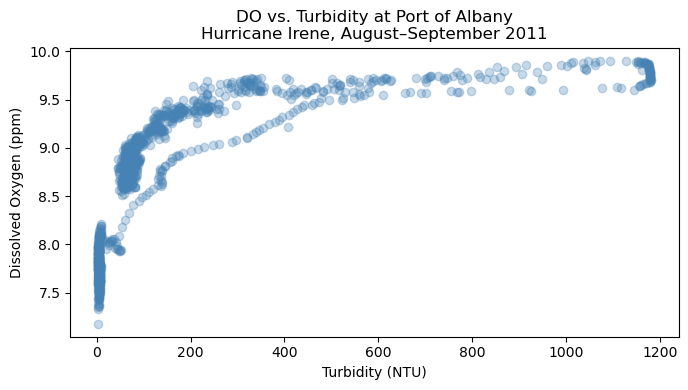

<Figure size 640x480 with 0 Axes>

In [6]:
# Create scatterplot of turbidity and dissolved oxygen relationship 
fig, ax = plt.subplots(figsize=(7, 4))

# Add scatter plot
ax.scatter(df['albany_turbidity'], df['albany_DO'], alpha=0.3,  color='steelblue')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('DO vs. Turbidity at Port of Albany\nHurricane Irene, August–September 2011')
plt.tight_layout()
plt.show()

ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('DO vs. Turbidity at Port of Albany\nHurricane Irene, August\u2013September 2011')
plt.tight_layout()
plt.show()

>**What do you notice?** Does the relationship look linear? Does a linear regression line seem like a good fit?

---

## Step 2: Prepare Features and Split Data

1. Build `X` from `albany_turbidity` (reshape to a 2D column vector with `.reshape(-1, 1)`) and `y` from `albany_DO`.
2. Split into 70% train / 30% test using `train_test_split` with `random_state=42`.

In [7]:
# Define predictor and response variable
X = df[['albany_turbidity']] # expected shape of (n,1)
y = df['albany_DO'] # expected shape of (n,) --> 1 dimensional

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)
# no stratify=y because we are doing a regression not a classification

print(f'Training observations : {len(X_train)}')
print(f'Test observations     : {len(X_test)}')

Training observations : 806
Test observations     : 346


---

## Step 3: Fit a Baseline Linear Regression

Fit a **degree-1 polynomial** (linear regression) and record its test MSE. This is our baseline.

1. Initialize a `LinearRegression` model and fit it on `X_train` / `y_train`.
2. Predict on `X_test` and compute test MSE.
3. Plot the fitted line over the test scatter.

Linear regression test MSE: 0.2895


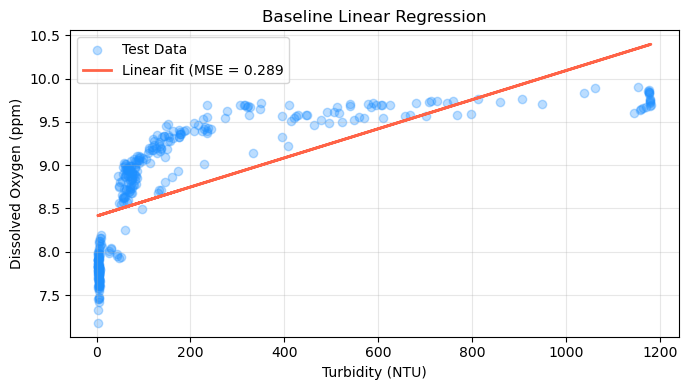

In [9]:
# Run Linear Regression (polynomial with degree = 1)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
# no scaling because regressions are not distance based methods like a KNN

# MSE = average squared difference between predicted values and the actual value
mse_linear = mean_squared_error(y_test, y_pred_lr)
print(f'Linear regression test MSE: {mse_linear:.4f}')

# visualize
fig, ax = plt.subplots(figsize=(7, 4))

# Add scatter plot and regression line
ax.scatter(X_test, y_test, alpha = 0.3, color = "dodgerblue", label = "Test Data")
ax.plot(X_test, y_pred_lr, color = "tomato", linewidth = 2, label = f'Linear fit (MSE = {mse_linear:.3f}')

ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('Baseline Linear Regression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Polynomial Regression

Linear regression assumes a straight-line relationship between the response and predictor:

$$\hat{y} = \beta_0 + \beta_1 x$$

But in many real-world settings, that relationship is non-linear. Consider the plot above where the relationship between turbidity and dissolved oxygen follows a curve, not a line. A straight-line model will miss that relationship.

A simple way to handle this is **polynomial regression**: include transformed (higher-degree) versions of the predictor as additional features. For degree $d$:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

While this may appear non-linear, it is still a **linear model**. It is linear in the *coefficients* $\beta_0, \beta_1, \ldots, \beta_d$. That means we can estimate all the coefficients using ordinary least squares, just as in multiple linear regression, where $X_1 = x$, $X_2 = x^2$, and so on.

Higher degree terms can often overfit, producing an unnecessarily wiggly curve that captures noise rather than signal. Cross Validation can help us find a degree that prevents overfitting.

In `scikit-learn`, `PolynomialFeatures` handles the feature transformation. **Always fit it on the training set and use `transform()` on the test set** — fitting on all the data would leak test information into the model.

---

## Step 4: Fit a Degree-2 Polynomial

- Use `PolynomialFeatures(degree=2)` to transform `X_train` and `X_test`
- Fit a `LinearRegression` on the transformed training data
- Compute and print the test MSE

In [10]:
# Run 2 degree polynomial model
poly = PolynomialFeatures(degree = 2)
# transform train and test x data into polynomial
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

mse_poly = mean_squared_error(y_test, y_pred_poly)

# Compare 1 and 2 degree polynomial results 
print(f'Linear regression test MSE  : {mse_linear:.4f}')
print(f'Degree-2 polynomial test MSE: {mse_poly:.4f}')

Linear regression test MSE  : 0.2895
Degree-2 polynomial test MSE: 0.1511


---

## Step 5: Compare Polynomial Degrees with Cross-Validation

Picking the best degree by checking test MSE is an example of data leakage since we would be using the test set to choose the model. Instead, we use **k-fold cross-validation on the training set** to estimate the error for every degree. Recall the steps for the hyperparameter use case of cross validation: 

0. Identify the hyperparameter you want to examine.
1. For each candidate value of the hyperparameter, compute the k-fold CV error on the training set.
2. Select the hyperparameter that resulted in the lowest CV error. If there are several candidates, opt for the one that gives the simpler model.
3. Refit the model using the selected hyperaparameter on the full training set.
4. Evaluate the final model once on the test set.


#### 0. Identify the hyperparameter you want to examine.
We identify the hyperparamter we want to tune as the number of degrees used in our polynomial regression. We will iterate over 11 different polynomial degress and perform cross validation with each one to find the lowest MSE. 

Note: `cross_val_score` with `scoring='neg_mean_squared_error'` returns **negative** MSE, so we negate the scores to get positive MSE values.

#### 1. For each candidate value of the hyperparameter, compute the k-fold CV error on the training set.

In [13]:
# k fold cross validation with polynomial degree tuning
degrees = list(range(1, 12)) # range 1-11, range does not include 12
cv_mean_mses = [] # empty list to store MSE's in

for degree in degrees:
    poly = PolynomialFeatures(degree = degree)
    
    X_train_poly = poly.fit_transform(X_train)
    # no X_test_poly as we do not want to run model with test data in validation
    lr = LinearRegression()
    
    # Calculate fold MSE scores
    scores = cross_val_score(lr, X_train_poly, y_train, cv = 5, scoring = 'neg_mean_squared_error')
    
    # Calculate mean MSE score for each polynomial and store in list
    cv_mean_mses.append(-scores.mean())

# Convert to array for easier functionality with min/max
cv_mean_mses = np.array(cv_mean_mses)

# Find the optimal degree from tuning
optimal_degree = degrees[np.argmin(cv_mean_mses)] # argmin returns index of the smallest value in an array

# Get lowest MSE value
best_cv_mse = cv_mean_mses.min()
    
# Prints degree and its associated MSE
for degree, mse in zip(degrees, cv_mean_mses):
    print(f"Degree {degree}: MSE = {mse:.4f}")

Degree 1: MSE = 0.2841
Degree 2: MSE = 0.1378
Degree 3: MSE = 0.0735
Degree 4: MSE = 0.0424
Degree 5: MSE = 0.0339
Degree 6: MSE = 0.1166
Degree 7: MSE = 0.2197
Degree 8: MSE = 0.2831
Degree 9: MSE = 0.3259
Degree 10: MSE = 0.3986
Degree 11: MSE = 0.4105


---

## Step 6: Visualize Tuning Results
- Create a line plot of CV MSE Across Polynomial Degrees
- Create a plot of how our model performs on polynomial degrees 1, 5, and 10

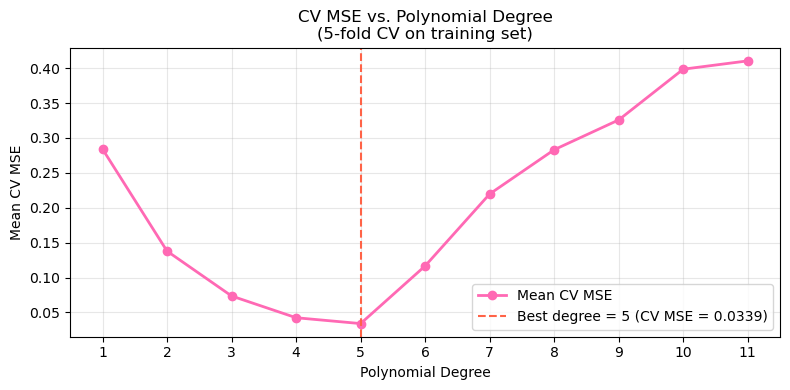

Best polynomial degree : 5
Best mean CV MSE       : 0.0339


In [16]:
# Plot 1: CV MSE across degrees
fig, ax = plt.subplots(figsize=(8, 4))

# Add MSE line plot and line at lowest MSE
ax.plot(degrees, cv_mean_mses, marker = 'o', color = 'hotpink', linewidth = 2, markersize = 6, label = 'Mean CV MSE')

ax.axvline(optimal_degree, color = 'tomato', linestyle = '--', linewidth = 1.5, 
           label = f'Best degree = {optimal_degree} (CV MSE = {best_cv_mse:.4f})')

ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Mean CV MSE')
ax.set_title('CV MSE vs. Polynomial Degree\n(5-fold CV on training set)')
ax.set_xticks(degrees)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best polynomial degree : {optimal_degree}')
print(f'Best mean CV MSE       : {best_cv_mse:.4f}')

# left side of dashed line is underfitting (model too simple and not capturing pattern of the data)
# right side of dashed line is overfitting (too detailed and picking up too much noise from data)

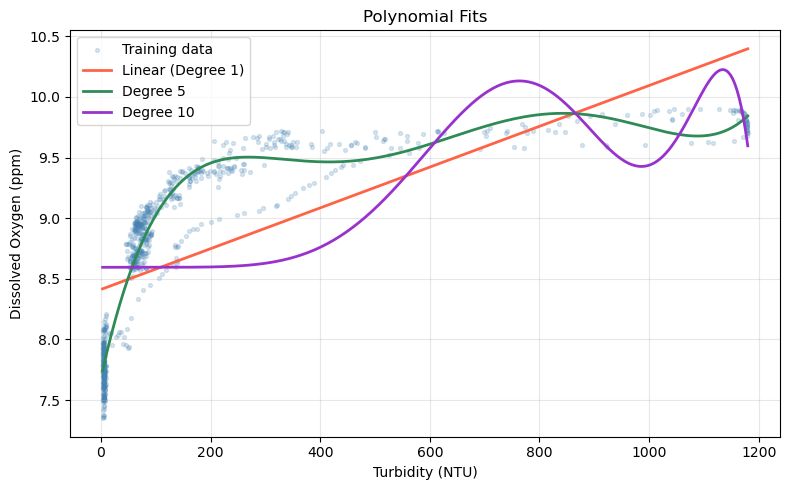

In [17]:
# Plot 2: Fitted curves for degrees 1, 5, 10 
X_range = pd.DataFrame(
    np.linspace(X_test.min(), X_test.max(), 300),
    columns=['albany_turbidity']
)
plot_degrees = [1, 5, 10]
labels       = ['Linear (Degree 1)', 'Degree 5', 'Degree 10']
colors_list  = ['tomato', 'seagreen', 'darkorchid']

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train, y_train, alpha=0.2, s=8, color='steelblue', label='Training data')

for deg, label, color in zip(plot_degrees, labels, colors_list):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    X_range_poly = poly.transform(X_range)
    y_pred = model.predict(X_range_poly)
    ax.plot(X_range, y_pred, linewidth=2, color=color, label=label)

ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title('Polynomial Fits')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Select the hyperparameter that resulted in the lowest CV error. If there are several candidates, opt for the one that gives the simpler model.

From the line plot above, we can see that the polynomial degree that yielded the lowest MSE was a degree of 5. We will use this degree for our test set. 

---

## Step 7: Evaluate the Best Degree on the Test Set

We will now address the last two step of our hyperparamter selection process with cross validation:
Refit the model using the selected hyperaparameter on the full training set (Step 3) & Evaluate the final model once on the test set (Step 4).

Fit a final model on **all training data** using the CV-selected degree and evaluate it once on the test set.

1. Fit `PolynomialFeatures(degree=optimal_degree)` on `X_train`, transform both sets.
2. Fit `LinearRegression` on the transformed training data.
3. Compute test MSE and compare against the linear baseline.
4. Plot the fitted curve over the test scatter.

In [19]:
# Fit polynomial with degree that yielded lowest MSE
poly_best = PolynomialFeatures(degree = optimal_degree)
X_train_p = poly_best.fit_transform(X_train)
X_test_p = poly_best.transform(X_test)

model_best = LinearRegression()
model_best.fit(X_train_p, y_train)
y_pred_best = model_best.predict(X_test_p)
mse_best = mean_squared_error(y_test, y_pred_best)

print(f'Linear regression test MSE   : {mse_linear:.4f}')
print(f'Degree-{optimal_degree} polynomial test MSE : {mse_best:.4f}')

Linear regression test MSE   : 0.2895
Degree-5 polynomial test MSE : 0.0320


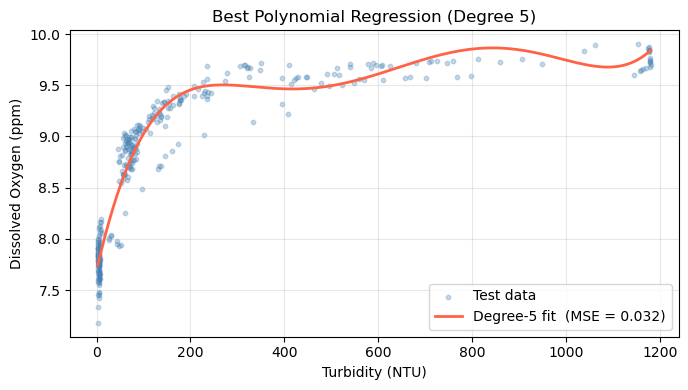

In [20]:
# Plot fitted curve over the test scatter

X_range = pd.DataFrame(
    np.linspace(X_test.min(), X_test.max(), 300),
    columns=['albany_turbidity']
)
y_range_pred = model_best.predict(poly_best.transform(X_range))

# Visualize results of final model evaluated on test set
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_test, y_test, alpha=0.3, s=10, color='steelblue', label='Test data')
ax.plot(X_range, y_range_pred, color='tomato', linewidth=2,
        label=f'Degree-{optimal_degree} fit  (MSE = {mse_best:.3f})')
ax.set_xlabel('Turbidity (NTU)')
ax.set_ylabel('Dissolved Oxygen (ppm)')
ax.set_title(f'Best Polynomial Regression (Degree {optimal_degree})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()